In [2]:
!pip install datascience

     |████████████████████████████████| 725 kB 1.0 MB/s eta 0:00:01
     |████████████████████████████████| 113 kB 2.8 MB/s eta 0:00:01
  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl (5.3 MB)
  Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl (30.3 MB)
  Using cached pandas-2.3.3-cp39-cp39-macosx_11_0_arm64.whl (10.8 MB)
     |████████████████████████████████| 9.9 MB 6.6 MB/s eta 0:00:01
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl (7.8 MB)
     |████████████████████████████████| 94 kB 4.1 MB/s eta 0:00:01
  Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
     |████████████████████████████████| 64 kB 5.7 MB/s eta 0:00:01
  Using cached markupsafe-3.0.3-cp39-cp39-macosx_11_0_arm64.whl (12 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached pillow-11.3.0-cp39-cp39-macosx_11_0_arm64.whl (4.7 MB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl (64 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl

In [3]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

from urllib.request import urlopen 
import re
def read_url(url): 
    return re.sub('\\s+', ' ', urlopen(url).read().decode())


/Users/ayushthasale07/Sarg<3/Data8/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [11]:
huck_finn_url = 'https://www.inferentialthinking.com/data/huck_finn.txt'
huck_finn_text = read_url(huck_finn_url)
huck_finn_chapters = huck_finn_text.split('CHAPTER ')[44:]

little_women_url = 'https://www.inferentialthinking.com/data/little_women.txt'
little_women_text = read_url(little_women_url)
little_women_chapters = little_women_text.split('CHAPTER ')[1:]

In [12]:
Table().with_column("Chapters", huck_finn_chapters)

Chapters
I. YOU don't know about me without you have read a book ...
II. WE went tiptoeing along a path amongst the trees bac ...
"III. WELL, I got a good going-over in the morning from o ..."
"IV. WELL, three or four months run along, and it was wel ..."
V. I had shut the door to. Then I turned around and ther ...
"VI. WELL, pretty soon the old man was up and around agai ..."
"VII. ""GIT up! What you 'bout?"" I opened my eyes and look ..."
VIII. THE sun was up so high when I waked that I judged ...
IX. I wanted to go and look at a place right about the m ...
X. AFTER breakfast I wanted to talk about the dead man a ...


In [13]:
"CHAPTER 1 xajhdodh  djsdpoijasfpoajs CHAPTER 2 asdpoijasfpoajs CHAPTER 3 asdpoijasfpoajs CHAPTER 4 asdpo".split('CHAPTER ')

['',
 '1 xajhdodh  djsdpoijasfpoajs ',
 '2 asdpoijasfpoajs ',
 '3 asdpoijasfpoajs ',
 '4 asdpo']

In [15]:
np.char.count(huck_finn_chapters, 'Tom')

array([ 6, 24,  5,  0,  0,  0,  2,  2,  0,  0,  2,  3,  1,  0,  0,  0,  3,
        5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  1,  4, 19, 15,
       14, 18,  9, 32, 11, 11,  8, 30,  6])

In [16]:
np.char.count(huck_finn_chapters, 'Jim')

array([ 0, 16,  0,  8,  0,  0,  0, 22, 11, 19,  4, 20,  9,  6, 16, 28,  0,
       10, 13, 18,  1,  0,  9,  5,  0,  0,  0,  1,  3,  5, 17,  0,  5, 17,
       18, 23,  4, 27, 10, 13,  0, 12,  6])

In [22]:

counts = Table().with_columns([
    'Tom', np.char.count(huck_finn_chapters, 'Tom'),
    'Jim', np.char.count(huck_finn_chapters, 'Jim'),
    'Huck', np.char.count(huck_finn_chapters, 'Huck'),
])
counts



Tom,Jim,Huck
6,0,3
24,16,2
5,0,2
0,8,1
0,0,0
0,0,2
2,0,0
2,22,5
0,11,1
0,19,0


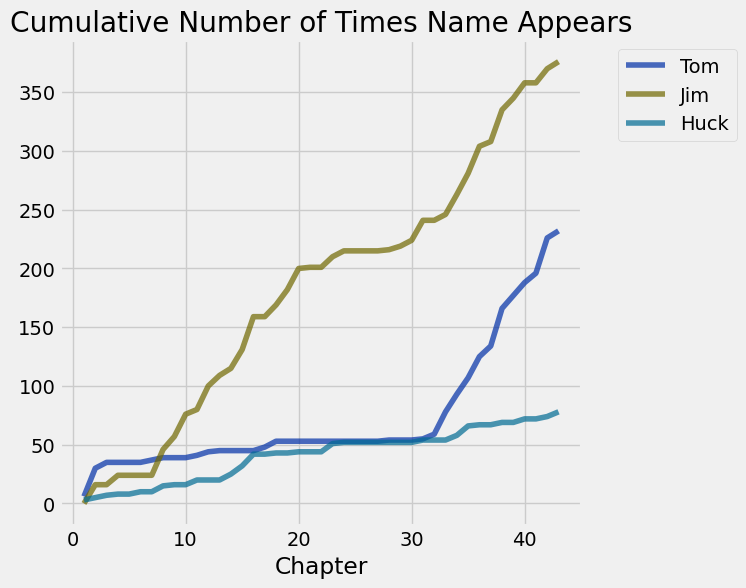

In [24]:
# compute cumulative sums per name using numpy
cum_Tom = np.cumsum(counts.column('Tom'))
cum_Jim = np.cumsum(counts.column('Jim'))
cum_Huck = np.cumsum(counts.column('Huck'))

# Chapter numbers computed from actual length
chapters = np.arange(1, len(cum_Tom) + 1)

cum_counts = Table().with_columns([
    'Tom', cum_Tom,
    'Jim', cum_Jim,
    'Huck', cum_Huck,
    'Chapter', chapters
])

cum_counts.plot(column_for_xticks=3)
plots.title('Cumulative Number of Times Name Appears');

In [25]:
Table().with_column('Chapters', little_women_chapters)

Chapters
"ONE PLAYING PILGRIMS ""Christmas won't be Christmas witho ..."
TWO A MERRY CHRISTMAS Jo was the first to wake in the gr ...
"THREE THE LAURENCE BOY ""Jo! Jo! Where are you?"" cried Me ..."
"FOUR BURDENS ""Oh, dear, how hard it does seem to take up ..."
"FIVE BEING NEIGHBORLY ""What in the world are you going t ..."
SIX BETH FINDS THE PALACE BEAUTIFUL The big house did pr ...
"SEVEN AMY'S VALLEY OF HUMILIATION ""That boy is a perfect ..."
"EIGHT JO MEETS APOLLYON ""Girls, where are you going?"" as ..."
"NINE MEG GOES TO VANITY FAIR ""I do think it was the most ..."
"TEN THE P.C. AND P.O. As spring came on, a new set of am ..."


In [26]:
# Counts of names in the chapters of Little Women

names = ['Amy', 'Beth', 'Jo', 'Laurie', 'Meg']
mentions = {name: np.char.count(little_women_chapters, name) for name in names}

counts = Table().with_columns([
        'Amy', mentions['Amy'],
        'Beth', mentions['Beth'],
        'Jo', mentions['Jo'],
        'Laurie', mentions['Laurie'],
        'Meg', mentions['Meg']
    ])



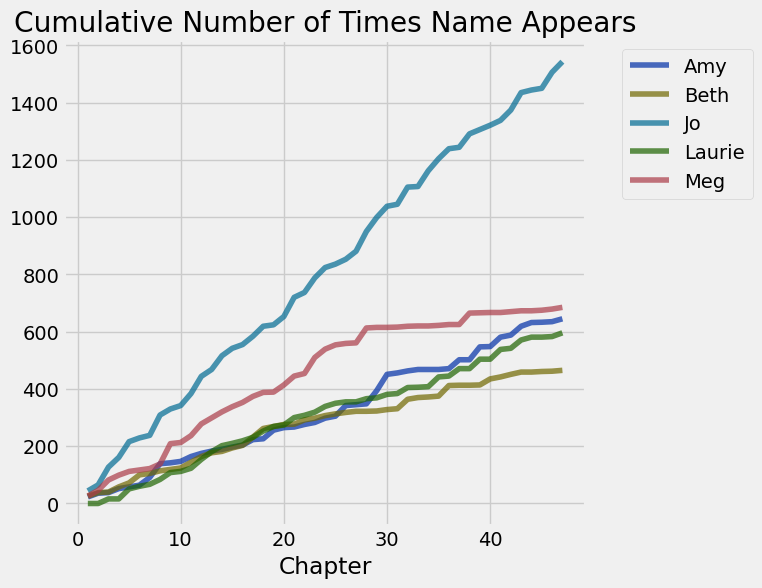

In [28]:
# Plot the cumulative counts

# compute cumulative sums per name using numpy
cum_Amy = np.cumsum(counts.column('Amy'))
cum_Beth = np.cumsum(counts.column('Beth'))
cum_Jo = np.cumsum(counts.column('Jo'))
cum_Laurie = np.cumsum(counts.column('Laurie'))
cum_Meg = np.cumsum(counts.column('Meg'))

chapters = np.arange(1, len(cum_Amy) + 1)

cum_counts = Table().with_columns([
    'Amy', cum_Amy,
    'Beth', cum_Beth,
    'Jo', cum_Jo,
    'Laurie', cum_Laurie,
    'Meg', cum_Meg,
    'Chapter', chapters
])

cum_counts.plot(column_for_xticks=5)
plots.title('Cumulative Number of Times Name Appears');

In [30]:
len(read_url('https://www.inferentialthinking.com/data/huck_finn.txt'))

588035

In [31]:
# In each chapter, count the number of all characters;
# call this the "length" of the chapter.
# Also count the number of periods.

length_hf = Table().with_columns([
        'Length', [len(s) for s in huck_finn_chapters],
        'Periods', np.char.count(huck_finn_chapters, '.')
    ])
length_lw = Table().with_columns([
        'Length', [len(s) for s in little_women_chapters],
        'Periods', np.char.count(little_women_chapters, '.')
    ])


In [32]:
length_hf

Length,Periods
7026,66
11982,117
8529,72
6799,84
8166,91
14550,125
13218,127
22208,249
8081,71
7036,70


In [33]:
length_lw

Length,Periods
21759,189
22148,188
20558,231
25526,195
23395,255
14622,140
14431,131
22476,214
33767,337
18508,185


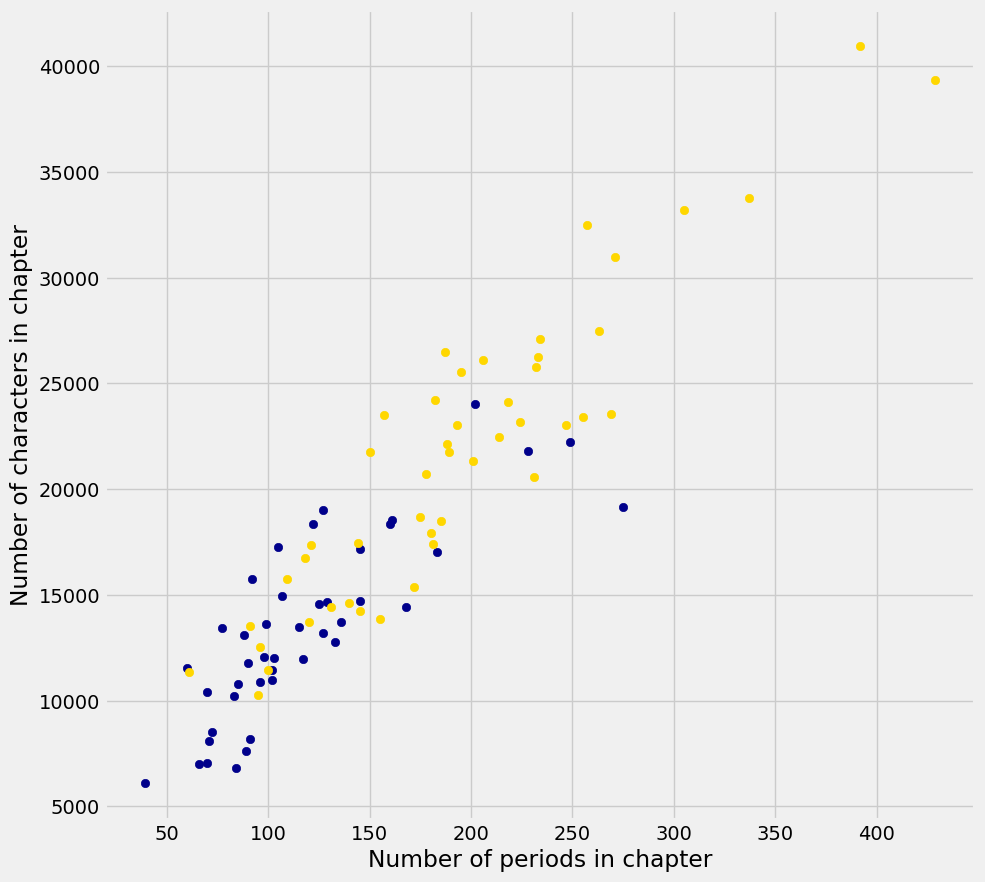

In [34]:
plots.figure(figsize=(10,10))
plots.scatter(length_hf[1], length_hf[0], color='darkblue')
plots.scatter(length_lw[1], length_lw[0], color='gold')
plots.xlabel('Number of periods in chapter')
plots.ylabel('Number of characters in chapter');